# Plotting Code for EXP1: Hidden State Similarity

In [1]:
import numpy as np
import pickle as pkl
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
os.chdir(r"""C:\Users\thgla\Documents\GitHub\ADALaS""")

In [2]:
fname_layer_to_final = r"data\hidden_states\alpaca\layer_to_final_similarities_alpaca.npz"
fname_layerwise = r"data\hidden_states\alpaca\layer_wise_similarities_alpaca.npz"

layer_to_final_dict = np.load(fname_layer_to_final, allow_pickle=True)
layerwise_dict = np.load(fname_layerwise, allow_pickle=True)

In [3]:
print(layer_to_final_dict.files)

['LS4', 'R8', 'LS8', 'RP20', 'LS16', 'RP8', 'RP16', 'RP4', 'R20', 'R4', 'R16', 'LS20', 'LS12', 'RP12', 'R12', 'B4', 'B8', 'B12', 'B16', 'B20']


In [4]:
print(layer_to_final_dict["R4"].shape)

(24, 57882)


In [31]:
strategies = ["R","RP","LS","B"]
strategy_names = ["RLS","RLS w/ L1","ULS","EE"]
budgets = [4,8,12,16,20]

#create df for final layer similarity
df = pd.DataFrame(columns=["cos_similarity","budget","strategy"])
for i in range(len(strategies)):
    for budget in budgets:
        cos_sim = layer_to_final_dict[strategies[i]+str(budget)]
        cos_sim_final = cos_sim[-1]
        df_temp = pd.DataFrame(cos_sim_final,columns=["cos_similarity"], dtype=np.float64)
        df_temp["budget"] = budget
        df_temp["strategy"] = strategy_names[i]
        df = pd.concat([df,df_temp],ignore_index=True,axis=0)

df_cumulative = pd.DataFrame(columns=["cos_sim","budget","strategy"])
for i in range(len(strategies)):
    # if strategies[i] == "R":
    #     continue
    for budget in budgets:
        cos_sim = layerwise_dict[strategies[i]+str(budget)]
        cos_sim = cos_sim[:-1,:] #remove final layer
        cos_sim_mean = np.mean(cos_sim,axis=0)
        df_temp = pd.DataFrame(cos_sim_mean,columns=["cos_sim"], dtype=np.float64)
        df_temp["budget"] = budget
        df_temp["strategy"] = strategy_names[i]
        df_cumulative = pd.concat([df_cumulative,df_temp],ignore_index=True,axis=0)

C:\Users\thgla\AppData\Local\Temp\ipykernel_43988\3240115769.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_temp],ignore_index=True,axis=0)
C:\Users\thgla\AppData\Local\Temp\ipykernel_43988\3240115769.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_cumulative = pd.concat([df_cumulative,df_temp],ignore_index=True,axis=0)


In [32]:
print(df.shape)
print(df_cumulative.shape)

(1157640, 3)
(1157640, 3)


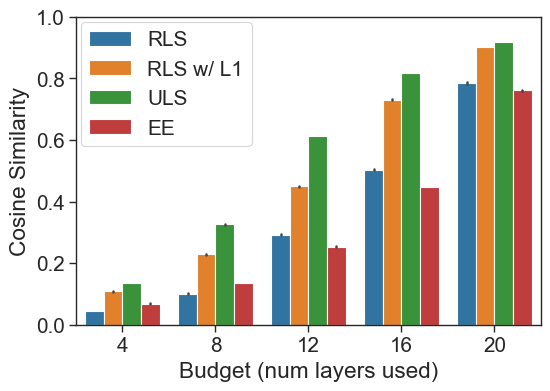

In [33]:
#plotting
sns.set_theme(context="paper", style="ticks",font_scale=1.7,palette="tab10")

plt.figure(figsize=(6,4))
sns.barplot(data=df,x="budget",y="cos_similarity",hue="strategy",errorbar=("ci",95))
plt.legend(fontsize=15, loc=(0.01,0.580))
plt.ylabel("Cosine Similarity")
plt.xlabel("Budget (num layers used)")
plt.ylim(0.0,1.0)
plt.savefig("data/hidden_states/alpaca/layer_to_final_similarities_alpaca.pdf",bbox_inches="tight")
plt.show()



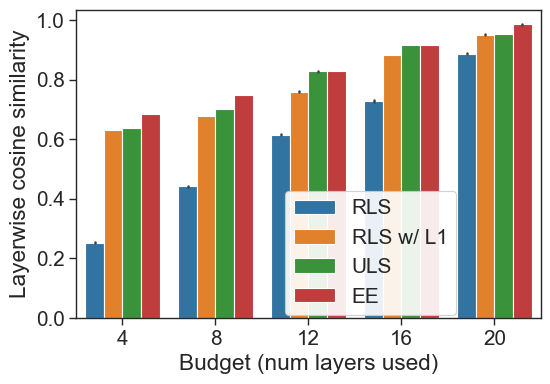

In [34]:
#plotting
sns.set_theme(context="paper", style="ticks",font_scale=1.7,palette="tab10")

plt.figure(figsize=(6,4))
sns.barplot(data=df_cumulative,x="budget",y="cos_sim",hue="strategy",errorbar=("ci",95))
#increase opacity of legend
plt.legend(fontsize=15, loc=(0.45,0.01),framealpha=0.9)
plt.ylabel("Layerwise cosine similarity")
plt.xlabel("Budget (num layers used)")
plt.savefig("data/hidden_states/alpaca/layerwise_similarities_alpaca.pdf",bbox_inches="tight")
plt.show()

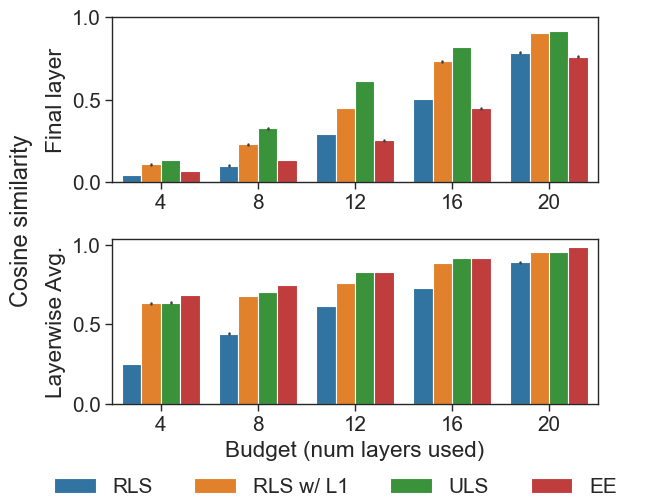

In [35]:
#plot previous 2 together, stacked vertically
sns.set_theme(context="paper", style="ticks",font_scale=1.7,palette="tab10")
fig, axs = plt.subplots(2,1,figsize=(6,5))

sns.barplot(data=df,x="budget",y="cos_similarity",hue="strategy",errorbar=("ci",95),ax=axs[0])
axs[0].set_ylabel("Final layer")
#remove x label
axs[0].set_xlabel("")
axs[0].set_ylim(0.0,1.0)
axs[0].set_yticks([0.0,0.5,1.0])
axs[0].get_legend().remove()

sns.barplot(data=df_cumulative,x="budget",y="cos_sim",hue="strategy",errorbar=("ci",95),ax=axs[1])
axs[1].set_ylabel("Layerwise Avg.")
axs[1].set_xlabel("Budget (num layers used)")
axs[1].get_legend().remove()


handles, labels = axs[1].get_legend_handles_labels()
fig.text(-0.02, 0.53, 'Cosine similarity', va='center', rotation='vertical',fontsize=17)
fig.legend(handles, labels, ncol=4, loc=(0.07,-0.010),fontsize=15,framealpha=0.9,edgecolor="none") 
plt.tight_layout()
plt.savefig("data/hidden_states/alpaca/layerwise_and_final_similarities_alpaca.pdf",bbox_inches="tight")
plt.show()




In [24]:
print(np.mean(df_cumulative[(df_cumulative["budget"]==12) & (df_cumulative["strategy"]=="EE")]["cos_sim"]))
print(np.mean(df_cumulative[(df_cumulative["budget"]==12) & (df_cumulative["strategy"]=="ULS")]["cos_sim"]))


0.8297105909258949
0.8279740774787827
EE at budget 12
0.8297105909258949
0.09914843079871595


In [168]:
#show layerwise similarities
# layerwise_df = pd.DataFrame(columns=["cos_dist", "layer", "budget","strategy"])
# for i in range(len(strategies)):
#     for budget in budgets:
#         cos_sim = layerwise_dict[strategies[i]+str(budget)]
#         flattened_cos_sim = (1-cos_sim).T.flatten()
#         layer_np = list(range(1,25))*cos_sim.shape[1]
#         budget_np = np.repeat(budget,cos_sim.shape[1]*24)
#         strategy_np = np.repeat(strategy_names[i],cos_sim.shape[1]*24)
#         df_temp = pd.DataFrame(flattened_cos_sim,columns=["cos_dist"], dtype=np.float64)
#         df_temp["layer"] = layer_np
#         df_temp["budget"] = budget_np
#         df_temp["strategy"] = strategy_np
#         layerwise_df = pd.concat([layerwise_df,df_temp],ignore_index=True,axis=0)

# layerwise_df = [pd.DataFrame(columns=[[f"cos_dist_{strategy}" for strategy in strategy_names]]) for i in range(len(budgets))]
# for i in range(len(budgets)):
#     for j in [0,2,3]:
#         cos_sim = layerwise_dict[strategies[j]+str(budgets[i])]
#         cos_sim = np.mean(1-cos_sim,axis=1)
#         #calculate averaged cumulative sum
#         cos_sim = np.cumsum(cos_sim) / np.arange(1,cos_sim.shape[0]+1)
#         layerwise_df[i][f"cos_dist_{strategy_names[j]}"] = cos_sim



        
        
        
        



(57882,)
(57882,)
(57882,)
(57882,)
(57882,)
(57882,)
(57882,)
(57882,)
(57882,)


C:\Users\thgla\AppData\Local\Temp\ipykernel_51308\3486057629.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_cumulative = pd.concat([df_cumulative,df_temp],ignore_index=True,axis=0)


(57882,)
(57882,)
(57882,)
(57882,)
(57882,)
(57882,)
(57882,)
(57882,)
(57882,)
(57882,)
(57882,)


In [165]:
print(layerwise_df[0].head())

  cos_dist_Early exit cos_dist_Random LS cos_dist_Random LS w/ L1  \
0           -0.000136                NaN                -0.000136   
1           -0.000112                NaN                 0.011070   
2           -0.000101                NaN                 0.021568   
3           -0.000094                NaN                 0.031502   
4            0.001435                NaN                 0.040304   

  cos_dist_Uniform LS  
0           -0.000136  
1            0.012597  
2            0.025493  
3            0.038789  
4            0.050073  


<Figure size 600x400 with 0 Axes>

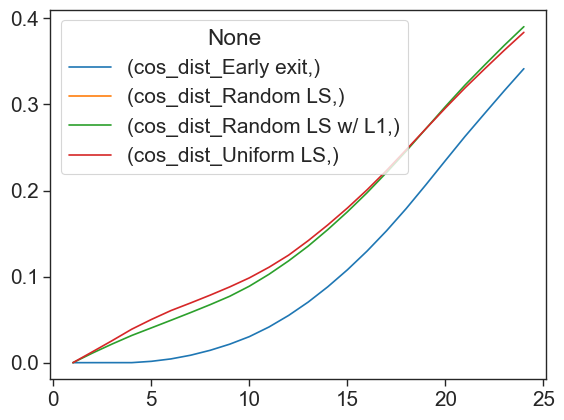

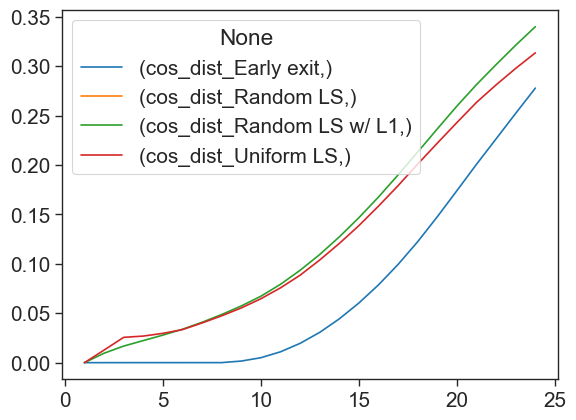

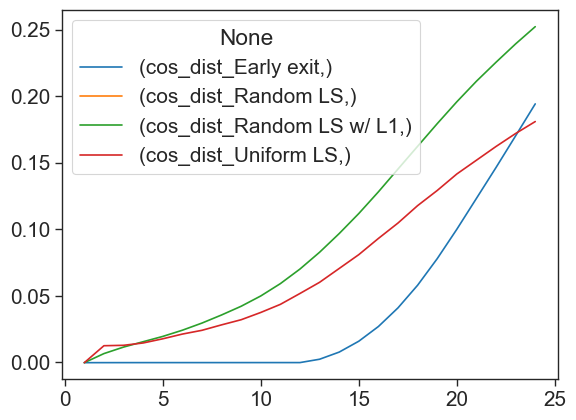

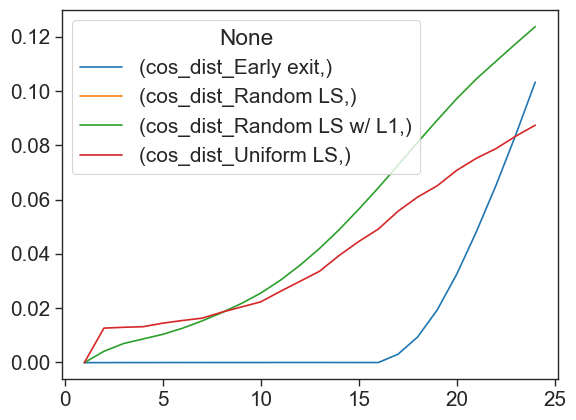

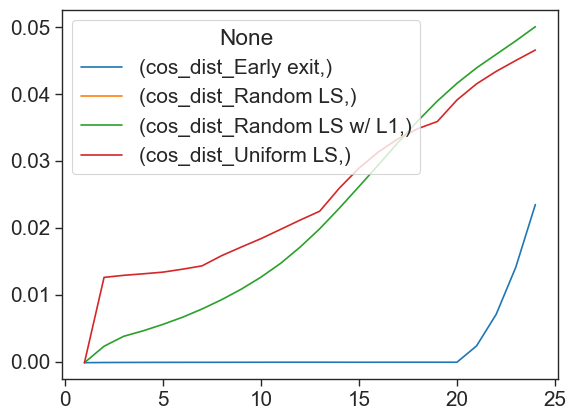

In [166]:
#plot the cumulative cosince distance
sns.set_theme(context="paper", style="ticks",font_scale=1.7,palette="tab10")
plt.figure(figsize=(6,4))
for i in range(len(budgets)):
    layerwise_df[i].index = list(range(1,25))
    layerwise_df[i].plot(y=[f"cos_dist_{strategy}" for strategy in strategy_names],stacked=False)
        

